Project Title

# Exploratory Data Analysis of NIFTY 50 Stock Market Data using Python

## Learning Objectives

Understand financial datasets

Perform EDA using Pandas & NumPy

Visualize stock trends using Matplotlib & Seaborn

Analyze market behavior

Apply basic Scikit-learn modeling

## Session 1: Data Loading & Understanding

Objective:

Load stock dataset

Understand financial columns

In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("NIFTY50_all.csv")

# Preview data
print(df.head())

# Structure
print(df.info())

# Summary statistics
print(df.describe())

# Column names
print(df.columns)

         Date      Symbol Series  Prev Close    Open     High    Low   Last  \
0  2007-11-27  MUNDRAPORT     EQ      440.00  770.00  1050.00  770.0  959.0   
1  2007-11-28  MUNDRAPORT     EQ      962.90  984.00   990.00  874.0  885.0   
2  2007-11-29  MUNDRAPORT     EQ      893.90  909.00   914.75  841.0  887.0   
3  2007-11-30  MUNDRAPORT     EQ      884.20  890.00   958.00  890.0  929.0   
4  2007-12-03  MUNDRAPORT     EQ      921.55  939.75   995.00  922.0  980.0   

    Close    VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  962.90  984.72  27294366  2.687719e+15     NaN           9859619.0   
1  893.90  941.38   4581338  4.312765e+14     NaN           1453278.0   
2  884.20  888.09   5124121  4.550658e+14     NaN           1069678.0   
3  921.55  929.17   4609762  4.283257e+14     NaN           1260913.0   
4  969.30  965.65   2977470  2.875200e+14     NaN            816123.0   

   %Deliverble  
0       0.3612  
1       0.3172  
2       0.2088  
3       0.2735  
4

## Session 2: Data Cleaning & Feature Engineering

Objective:

Convert date

Create new financial features

In [2]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Handle missing values
df = df.dropna()

# Sort by Date
df = df.sort_values(by='Date')

# Create new features
df['Daily_Return'] = df['Close'].pct_change()

df['Price_Range'] = df['High'] - df['Low']

df['Month'] = df['Date'].dt.month

print(df.head())

             Date      Symbol Series  Prev Close     Open     High      Low  \
866    2011-06-01  MUNDRAPORT     EQ      161.45   162.10   165.70   161.25   
148238 2011-06-01      MARUTI     EQ     1230.15  1220.00  1255.00  1220.00   
93827  2011-06-01    HINDALCO     EQ      197.35   198.25   198.75   195.35   
23116  2011-06-01  BAJFINANCE     EQ      616.70   617.00   636.50   616.00   
212532 2011-06-01  ULTRACEMCO     EQ     1025.60  1016.15  1042.00  1016.15   

          Last    Close     VWAP   Volume      Turnover   Trades  \
866      163.5   164.00   164.08  2574106  4.223703e+13  19171.0   
148238  1255.0  1250.10  1242.16   444037  5.515649e+13  16622.0   
93827    197.3   197.30   196.97  5579947  1.099062e+14  57196.0   
23116    627.0   631.85   627.01     6894  4.322621e+11   1416.0   
212532  1037.7  1035.70  1028.31    79530  8.178147e+12   2689.0   

        Deliverable Volume  %Deliverble  Daily_Return  Price_Range  Month  
866              1271255.0       0.4939 

## Session 3: EDA using Pandas & NumPy

Objective:

Analyze stock behavior

In [3]:
# Average closing price per company
avg_close = df.groupby('Symbol')['Close'].mean()
print(avg_close)

# Highest traded volume
high_volume = df.groupby('Symbol')['Volume'].sum().idxmax()
print("Highest Volume Company:", high_volume)

# Daily return statistics
print(df['Daily_Return'].describe())

# Volatility (std deviation)
volatility = df.groupby('Symbol')['Daily_Return'].std()
print(volatility)

Symbol
ADANIPORTS      294.111766
ASIANPAINT     1753.595664
AXISBANK        773.738742
BAJAJ-AUTO     2466.313823
BAJAJFINSV     3482.742630
BAJFINANCE     2760.656820
BHARTIARTL      376.301527
BPCL            536.004947
BRITANNIA      2508.505884
CIPLA           524.305904
COALINDIA       285.247313
DRREDDY        2773.957614
EICHERMOT     14219.001181
GAIL            330.583856
GRASIM         2130.677056
HCLTECH         896.796356
HDFC           1386.438050
HDFCBANK       1205.230517
HEROHONDA      1816.487500
HEROMOTOCO     2665.182060
HINDALCO        163.028115
HINDUNILVR     1109.265045
ICICIBANK       604.151120
INDUSINDBK      929.332166
INFOSYSTCH     2823.970000
INFY           1708.548912
IOC             270.568343
ITC             276.283591
JSWSTEEL        663.488131
KOTAKBANK       996.044646
LT             1359.609507
M&M             945.334528
MARUTI         4613.037643
MUNDRAPORT      145.743312
NESTLEIND      8121.968791
NTPC            143.430476
ONGC            224.5

## Session 4: Visualization (Matplotlib – 5 Graphs)

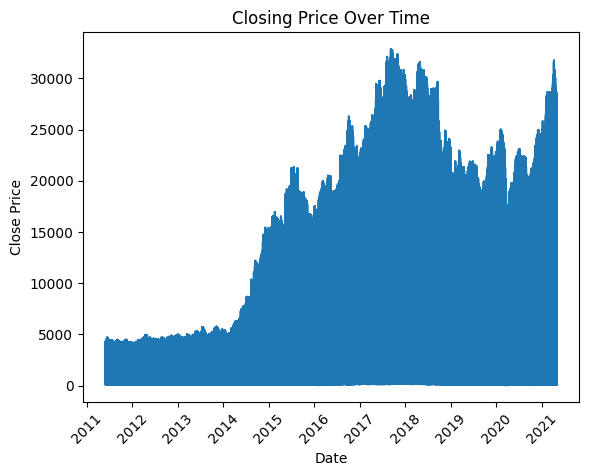

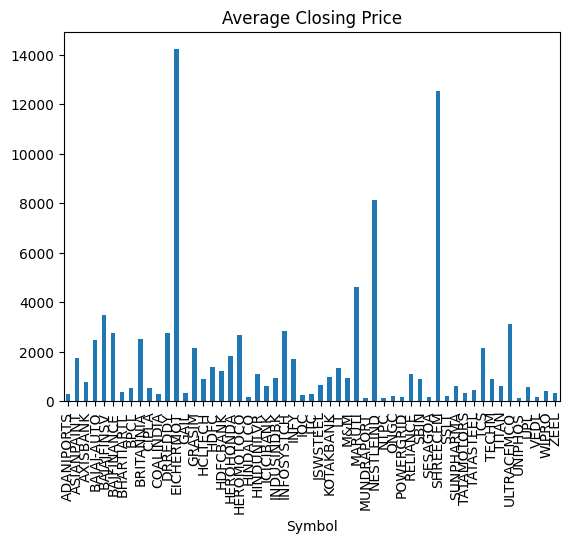

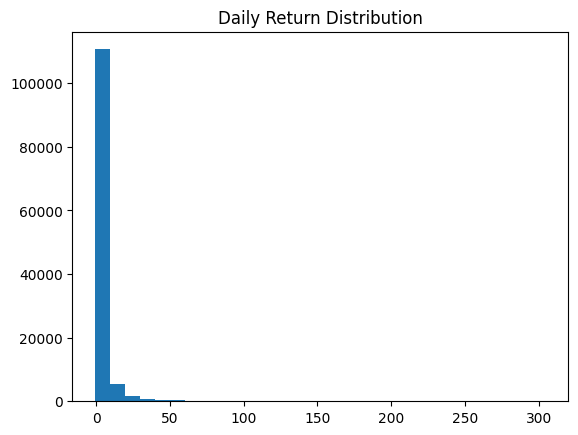

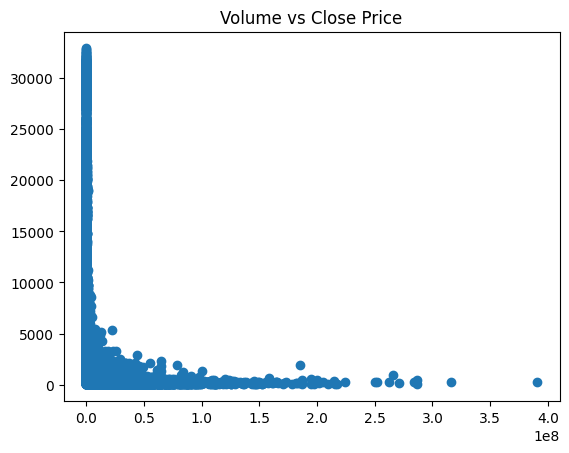

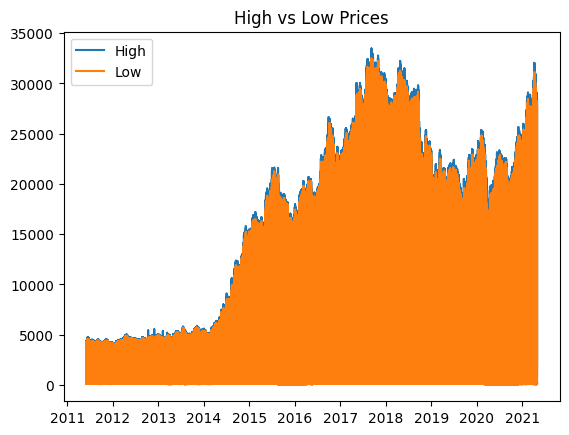

In [4]:
import matplotlib.pyplot as plt

# 1 Line plot - Closing price over time
plt.plot(df['Date'], df['Close'])
plt.title("Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.show()

# 2 Bar chart - Avg closing price by company
avg_close.plot(kind='bar')
plt.title("Average Closing Price")
plt.show()

# 3 Histogram - Daily returns
plt.hist(df['Daily_Return'].dropna(), bins=30)
plt.title("Daily Return Distribution")
plt.show()

# 4 Scatter plot - Volume vs Close
plt.scatter(df['Volume'], df['Close'])
plt.title("Volume vs Close Price")
plt.show()

# 5 Line plot - High vs Low
plt.plot(df['Date'], df['High'], label='High')
plt.plot(df['Date'], df['Low'], label='Low')
plt.legend()
plt.title("High vs Low Prices")
plt.show()

## Session 5: Advanced Visualization (Seaborn – 5 Graphs)

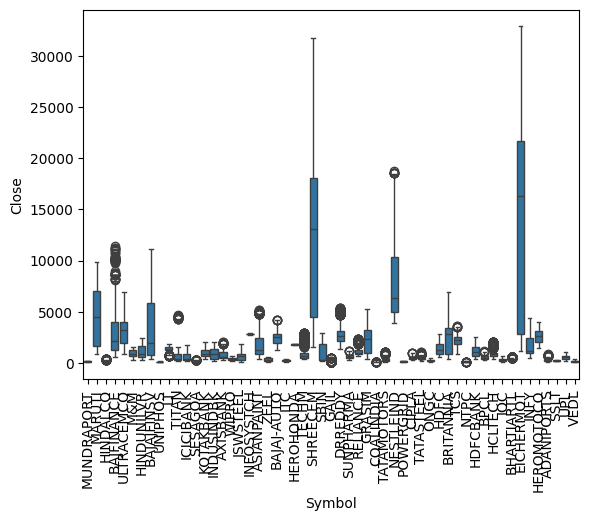

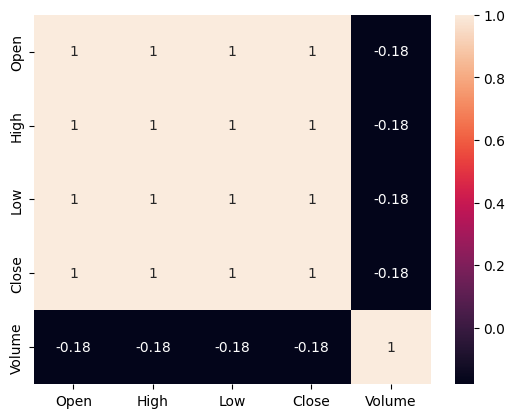

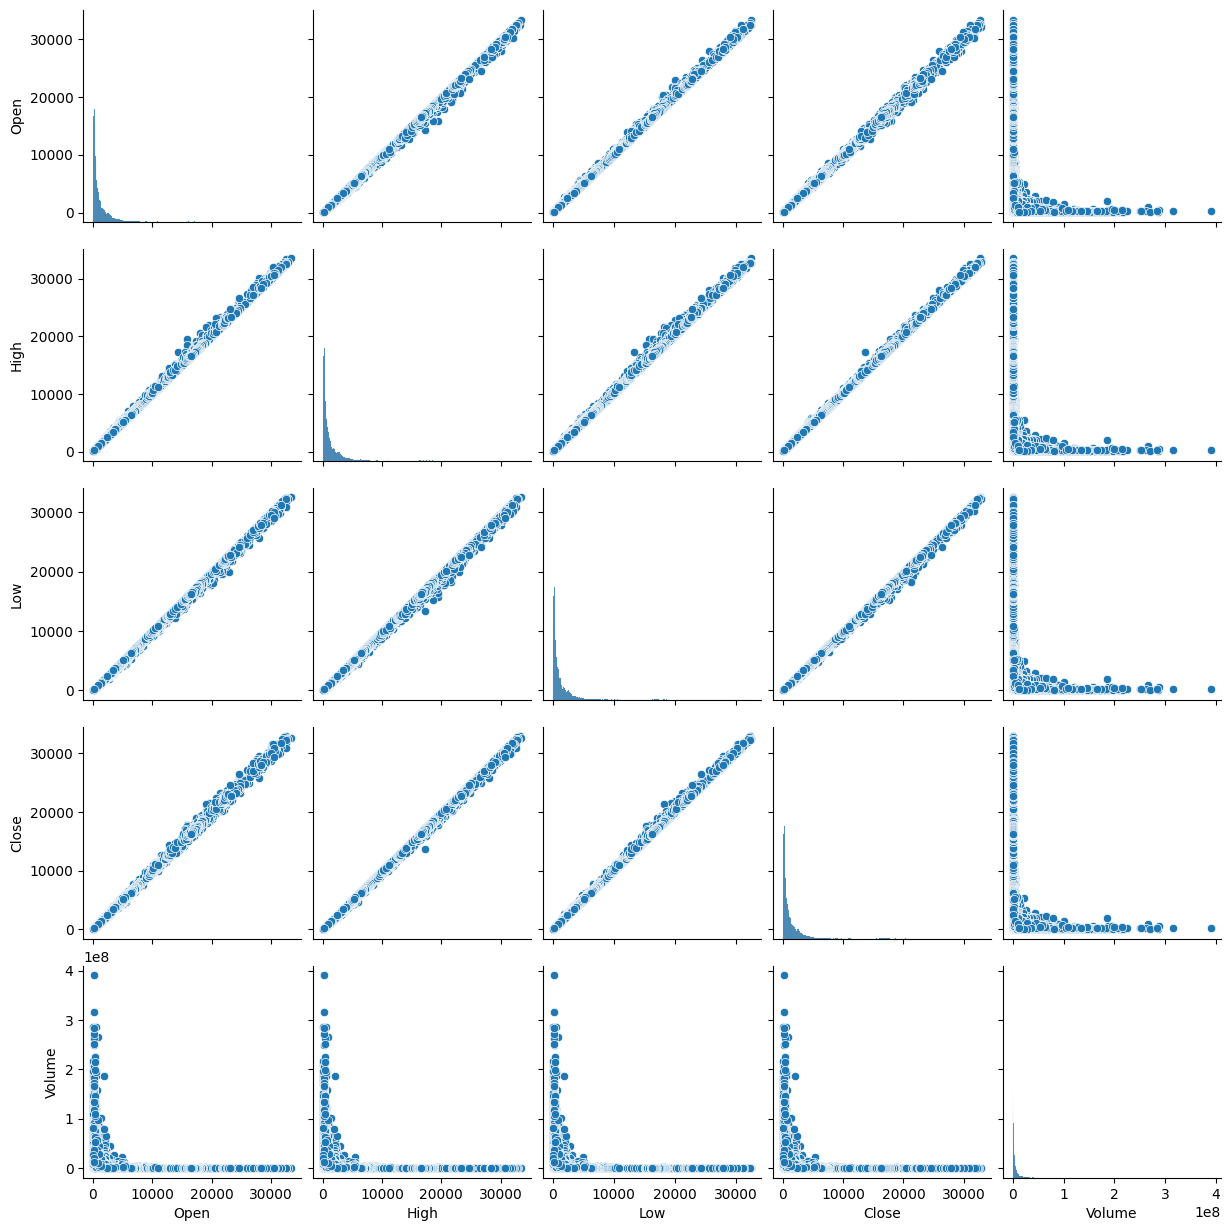

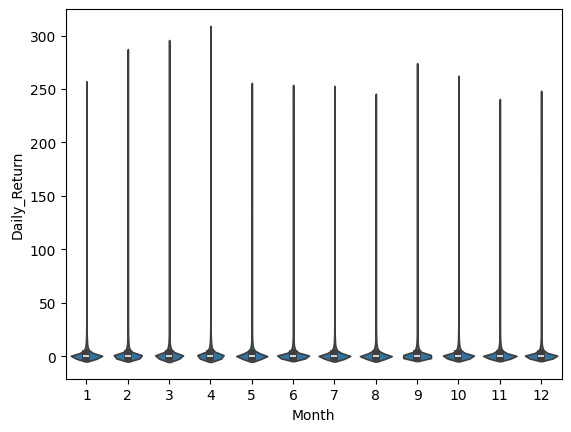

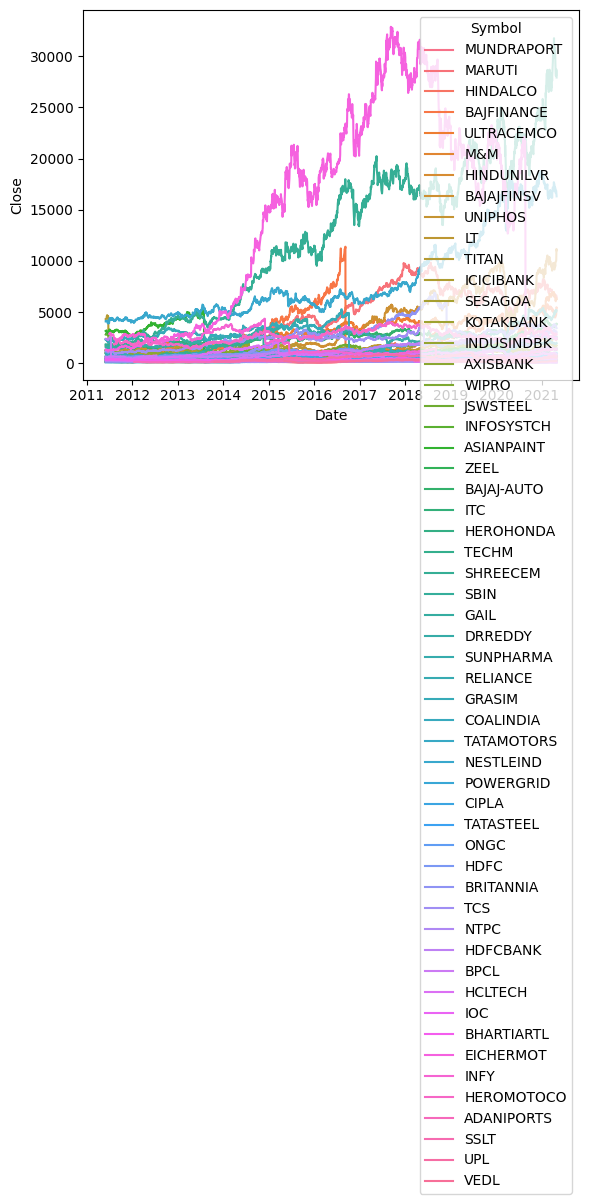

In [5]:
import seaborn as sns

# 6 Boxplot - Close price by company
sns.boxplot(x='Symbol', y='Close', data=df)
plt.xticks(rotation=90)
plt.show()

# 7 Heatmap - Correlation
corr = df[['Open','High','Low','Close','Volume']].corr()
sns.heatmap(corr, annot=True)
plt.show()

# 8 Pairplot
sns.pairplot(df[['Open','High','Low','Close','Volume']])
plt.show()

# 9 Violin plot - Daily return by month
sns.violinplot(x='Month', y='Daily_Return', data=df)
plt.show()

# 10 Lineplot with hue (multiple companies)
sns.lineplot(x='Date', y='Close', hue='Symbol', data=df)
plt.show()

## Session 6: Machine Learning + Insights

Objective:

Predict closing price

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Features & Target
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

# Evaluation
print("R2 Score:", r2_score(y_test, pred))

R2 Score: 0.9999365058209901


## 5 MACHINE LEARNING MODELS

In [7]:
## Step 1: Common Setup
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Load dataset
df = pd.read_csv("NIFTY50_all.csv")

# Preprocessing
df['Date'] = pd.to_datetime(df['Date'])
df = df.dropna()

# Features & Target
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [8]:
## Model 1: Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, pred_lr))
print("MSE:", mean_squared_error(y_test, pred_lr))

Linear Regression R2: 0.9999275005816441
MSE: 866.0406175006802


In [9]:
## Model 2: Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree R2:", r2_score(y_test, pred_dt))
print("MSE:", mean_squared_error(y_test, pred_dt))

Decision Tree R2: 0.9998219764098341
MSE: 2126.5778878432843


In [10]:
## Model 3: Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, pred_rf))
print("MSE:", mean_squared_error(y_test, pred_rf))

Random Forest R2: 0.9999018450250998
MSE: 1172.5086490496844


In [11]:
## Model 4: K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

print("KNN R2:", r2_score(y_test, pred_knn))
print("MSE:", mean_squared_error(y_test, pred_knn))

KNN R2: 0.9902924682003706
MSE: 115961.16251437117


In [12]:
## Model 5: Support Vector Regressor (SVR)
from sklearn.svm import SVR

svr = SVR()
svr.fit(X_train, y_train)

pred_svr = svr.predict(X_test)

print("SVR R2:", r2_score(y_test, pred_svr))
print("MSE:", mean_squared_error(y_test, pred_svr))

SVR R2: 0.01608628411205637
MSE: 11753325.21831731


In [13]:
## Model Comparison
results = {
    "Linear Regression": r2_score(y_test, pred_lr),
    "Decision Tree": r2_score(y_test, pred_dt),
    "Random Forest": r2_score(y_test, pred_rf),
    "KNN": r2_score(y_test, pred_knn),
    "SVR": r2_score(y_test, pred_svr)
}

for model, score in results.items():
    print(model, "R2 Score:", score)

Linear Regression R2 Score: 0.9999275005816441
Decision Tree R2 Score: 0.9998219764098341
Random Forest R2 Score: 0.9999018450250998
KNN R2 Score: 0.9902924682003706
SVR R2 Score: 0.01608628411205637


## QUESTIONS

Q1. Split the dataset into training and testing sets

In [14]:
from sklearn.model_selection import train_test_split

X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (96275, 4)
Testing size: (24069, 4)


Q2. Train a Linear Regression model

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


Q3. Predict closing prices using Linear Regression

In [16]:
pred = model.predict(X_test)

print("Predicted values:", pred[:5])

Predicted values: [  483.82723186   573.68427397   222.06091572  1172.40300358
 18940.21388662]


Q4. Evaluate model using R² score

In [17]:
from sklearn.metrics import r2_score

score = r2_score(y_test, pred)
print("R2 Score:", score)

R2 Score: 0.999933335078602


Q5. Calculate Mean Squared Error (MSE)

In [18]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, pred)
print("MSE:", mse)

MSE: 771.8680577441781


Q6. Train a Decision Tree Regressor

In [19]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree R2:", r2_score(y_test, pred_dt))

Decision Tree R2: 0.9998446404441795


Q7. Train a Random Forest Regressor

In [20]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, pred_rf))

Random Forest R2: 0.9999067539036192


Q8. Apply K-Nearest Neighbors Regressor

In [21]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

print("KNN R2:", r2_score(y_test, pred_knn))

KNN R2: 0.9917306646359881


Q9. Apply Support Vector Regressor (SVR)

In [22]:
from sklearn.svm import SVR

svr = SVR()
svr.fit(X_train, y_train)

pred_svr = svr.predict(X_test)

print("SVR R2:", r2_score(y_test, pred_svr))

SVR R2: 0.01674593641794353


Q10. Compare all model performances

In [23]:
results = {
    "Linear Regression": r2_score(y_test, pred),
    "Decision Tree": r2_score(y_test, pred_dt),
    "Random Forest": r2_score(y_test, pred_rf),
    "KNN": r2_score(y_test, pred_knn),
    "SVR": r2_score(y_test, pred_svr)
}

for model, score in results.items():
    print(model, ":", score)

Linear Regression : 0.999933335078602
Decision Tree : 0.9998446404441795
Random Forest : 0.9999067539036192
KNN : 0.9917306646359881
SVR : 0.01674593641794353


Q11. Apply Feature Scaling using StandardScaler

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Data Sample:\n", X_scaled[:5])

Scaled Data Sample:
 [[-0.47344884 -0.47300965 -0.47336943 -0.21737593]
 [-0.47289711 -0.47316728 -0.47369365 -0.310084  ]
 [-0.47362307 -0.47384082 -0.47397366 -0.36450032]
 [-0.47391345 -0.47432807 -0.47401787 -0.43226508]
 [-0.4741022  -0.47385515 -0.47481368 -0.25771438]]


Q12. Train Linear Regression on Scaled Data

In [26]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_scaled, y, test_size=0.2)

model_scaled = LinearRegression()
model_scaled.fit(X_train_s, y_train_s)

pred_scaled = model_scaled.predict(X_test_s)

print("R2 Score (Scaled):", r2_score(y_test_s, pred_scaled))

R2 Score (Scaled): 0.9999343480527789


Q13. Find Feature Importance using Random Forest

In [27]:
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

importance = rf.feature_importances_

for col, val in zip(X.columns, importance):
    print(col, ":", val)

Open : 3.085801831976289e-05
High : 0.7179221609871356
Low : 0.2820322643908742
Volume : 1.4716603670435886e-05


Q14. Predict Closing Price for New Data

In [28]:
new_data = [[500, 520, 495, 1000000]]  # Example values

prediction = rf.predict(new_data)

print("Predicted Close Price:", prediction[0])

Predicted Close Price: 513.2884999999999


C:\Users\Saksh\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Q15. Check Overfitting in Decision Tree

In [29]:
train_score = dt.score(X_train, y_train)
test_score = dt.score(X_test, y_test)

print("Training Score:", train_score)
print("Testing Score:", test_score)

Training Score: 1.0
Testing Score: 0.9998446404441795


Q16. Tune KNN (change number of neighbors)

In [30]:
for k in range(1, 10):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    
    print("K =", k, "R2:", r2_score(y_test, pred_k))

K = 1 R2: 0.993770665587314
K = 2 R2: 0.9935367111673373
K = 3 R2: 0.9931131096132266
K = 4 R2: 0.9924622766400056
K = 5 R2: 0.9917306646359881
K = 6 R2: 0.9909051328512216
K = 7 R2: 0.9900687566803673
K = 8 R2: 0.9892729260389495
K = 9 R2: 0.988550560991259


Q17. Evaluate model using MAE (Mean Absolute Error)

In [31]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, pred_rf)

print("MAE:", mae)

MAE: 10.287388923511571


Q18. Train model using only important features

In [32]:
# Select top 2 features manually (example)
X_new = df[['Open', 'High']]

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_new, y, test_size=0.2)

model_new = LinearRegression()
model_new.fit(X_train_n, y_train_n)

pred_new = model_new.predict(X_test_n)

print("R2 with selected features:", r2_score(y_test_n, pred_new))

R2 with selected features: 0.9998345624451659


Q19. Create Polynomial Regression Model

In [33]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y, test_size=0.2)

model_poly = LinearRegression()
model_poly.fit(X_train_p, y_train_p)

pred_poly = model_poly.predict(X_test_p)

print("Polynomial R2:", r2_score(y_test_p, pred_poly))

Polynomial R2: 0.8660471588090806


Q20. Save and Load Model using Joblib

In [34]:
import joblib

# Save model
joblib.dump(rf, "nifty_model.pkl")

# Load model
loaded_model = joblib.load("nifty_model.pkl")

# Predict using loaded model
pred_loaded = loaded_model.predict(X_test)

print("Loaded Model R2:", r2_score(y_test, pred_loaded))

Loaded Model R2: 0.9999056386382729


##  Key Insights – NIFTY50 EDA

1. Strong Correlation among Price Variables
Open, High, Low, and Close prices are highly correlated
Indicates consistent price movement patterns within a trading day

2. Closing Price Trend Over Time
The closing price shows overall trend (upward/downward) depending on market conditions
Useful for identifying bullish or bearish markets

3. High Volatility in Certain Stocks
Some stocks show large fluctuations in Daily Returns
Indicates higher risk and trading opportunities

4. Volume Spikes Indicate Market Activity
Sudden increase in Volume reflects high trading interest
Often linked to news, events, or market sentiment

5. Price Range Reflects Intraday Volatility
Large difference between High and Low prices suggests unstable trading
Traders can use this for intraday strategies

6. Daily Returns Distribution
Daily returns are mostly centered around zero with some extreme values
Indicates normal market behavior with occasional shocks

7. Top Performing Stocks
Certain companies consistently maintain higher average closing prices
These are typically market leaders or blue-chip stocks

8. Seasonal / Monthly Patterns
Some months may show consistent gains or losses
Helps in understanding seasonal market trends

9. Volume vs Price Relationship
Weak to moderate relationship between Volume and Closing Price
High volume doesn’t always guarantee price increase

10. Model Prediction Accuracy
Machine learning models (especially Random Forest) can predict closing prices with good accuracy
Demonstrates usefulness of AI in financial forecasting

## Final Business Conclusion

Stock prices are influenced by market trends, volatility, and trading volume

High volatility stocks offer high risk–high return opportunities

Machine learning can assist in predicting price movements, but cannot fully eliminate risk